# Demo: Segmentacja binarna 128x128

In [1]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from unet import UNet
from predict import predict_img

# Ustawienia
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_path = 'unet_carvana_scale0.5_epoch2.pth'
image_path = 'Dataset/image.png'
target_size = (128, 128)

print(f"Using device: {device}")


Using device: cpu


## Ładowanie modelu

In [2]:
# Inicjalizacja modelu
net = UNet(n_channels=3, n_classes=2, bilinear=False)
net.to(device=device)

# Ładowanie pre-trenowanych wag
state_dict = torch.load(model_path, map_location=device)
if 'mask_values' in state_dict:
    state_dict.pop('mask_values')
net.load_state_dict(state_dict)
print("Model załadowany pomyślnie!")


Model załadowany pomyślnie!


## Inferencja na obrazku 128x128

In [3]:
# Wczytanie i przygotowanie obrazu drogowego (zmiana rozmiaru na 128x128)
img = Image.open(image_path).convert('RGB')
img_resized = img.resize(target_size, Image.BILINEAR)

# Predykcja na obrazie 128x128
# Uwaga: predict_img w predict.py przyjmuje argument scale_factor.
# Aby zachować rozmiar 128x128, ustawiamy scale_factor=1, ponieważ już zmieniliśmy rozmiar wejściowego obrazka.
mask = predict_img(net=net, full_img=img_resized, scale_factor=1, out_threshold=0.5, device=device)

print(f"Kształt wygenerowanej maski: {mask.shape}")


Kształt wygenerowanej maski: (128, 128)


/var/folders/1d/r2qg0m8d5jb67j1_98mk06zr0000gn/T/ipykernel_42988/4161066222.py:3: DeprecationWarning: BILINEAR is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BILINEAR instead.
  img_resized = img.resize(target_size, Image.BILINEAR)


## Wizualizacja

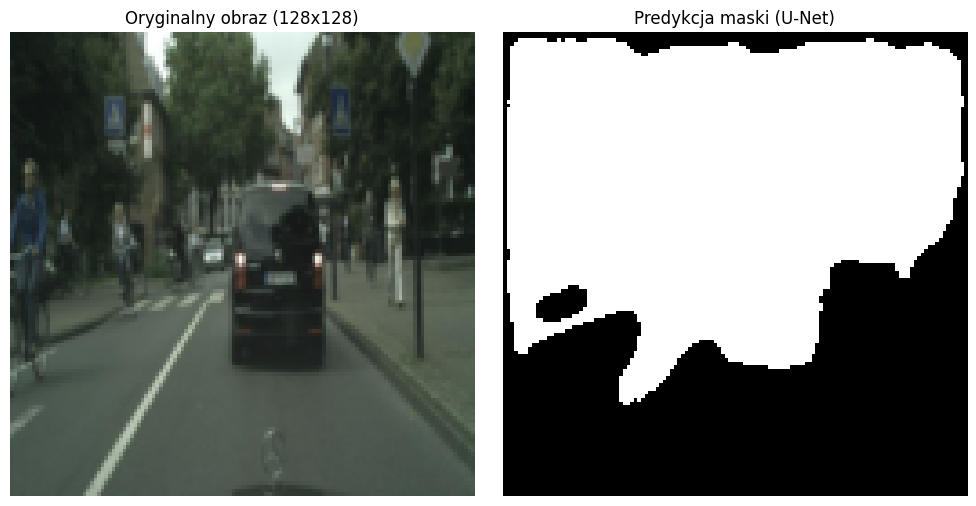

In [4]:
# Wizualizacja wyników
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_resized)
axes[0].set_title('Oryginalny obraz (128x128)')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Predykcja maski (U-Net)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


# BCE vs Dice loss

# Augmentacje

# Analiza błędów na granicach obiektów